In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/audio_features_output.csv")
meta_df = pd.read_csv("../data/pilot.csv")

In [3]:
df = df.merge(meta_df[["clue_id", "Spymaster ID"]], on="clue_id", how="left")
df.head()

,clue_id,confidence,difficulty,transcript,clue_word_frequency,duration,clue_latency,clue_number_latency,speech_rate,speech_ratio,...,pitch_mean,pitch_std,pitch_slope,pitch_rise_end,energy_mean,energy_std,jitter,shimmer,hnr,Spymaster ID
0,1,3,2,"Okay, let me see here. So, mm-hmm. Alright, t...",5.08,28.992000,24.82,0.00,0.689845,0.643626,...,131.744142,38.509710,1.652803,6.989008,0.016587,0.030246,0.020543,0.121808,15.683529,2
1,2,4,1,homo sapiens to,1.59,8.000000,5.22,0.56,0.375000,0.300000,...,136.147481,21.975717,3.831427,-22.942768,0.010015,0.018579,0.029517,0.145391,11.074242,2
2,3,4,2,2. Human 2.,5.35,3.989313,2.82,-1.16,0.752009,0.338404,...,123.546941,8.446031,-34.103891,-0.924727,0.009769,0.020586,0.025945,0.112453,14.221208,2
3,4,2,4,This is tough here. It is called Schultzer 2.,3.92,18.005312,15.46,0.38,0.499852,0.436538,...,122.802768,22.507623,0.576415,-6.448488,0.005187,0.009289,0.033573,0.140501,9.131941,2
4,5,4,3,"See, I don't know how to link some of these. ...",3.91,33.984000,3.14,0.22,0.941620,0.404308,...,132.258530,30.830731,-0.598519,-22.540423,0.007066,0.011827,0.025149,0.102263,14.127368,2


In [4]:
len(df)

50

## 1. Speaker Level Normalization

In [5]:
EXCLUDE = ["clue_id", "confidence", "difficulty", "transcript", "Spymaster ID"]
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
df[FEATURE_COLS] = df[FEATURE_COLS].astype(float)

In [6]:
df_norm = df.copy()

for speaker, group in df.groupby("Spymaster ID"):
    idx = group.index

    mean = group[FEATURE_COLS].mean()
    std = group[FEATURE_COLS].std().replace(0, 1)

    df_norm.loc[idx, FEATURE_COLS] = (group[FEATURE_COLS] - mean) / std

In [7]:
# sanity check 1: values should be close to 1
# df_norm.groupby("Spymaster ID")[FEATURE_COLS].std().round(2)

In [8]:
# sanity check 1: values should be close to 0
# df_norm.groupby("Spymaster ID")[FEATURE_COLS].mean().round(2)

## 2. Correlation Analysis

In [9]:
corr = df_norm[FEATURE_COLS].corr()

In [10]:
# find highly correlated pairs
threshold = 0.9

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            high_corr_pairs.append((col1, col2, corr.iloc[i, j]))

high_corr_pairs[:10]

[('pause_count', 'duration', np.float64(0.9866426877808585))]

**Observations**: 

Pause count and duration are highly correlated, which makes sense: longer audio = more pauses --> drop pause_count 

MFCC features seem to be highly correlated too, but they are inherently correlated, and they represent a joint spectral space. Let's keep them for now, some models like RF and boosting handle them well. 

In [11]:
FEATURE_COLS_REDUCED = [c for c in FEATURE_COLS if c != "pause_count"]

## 3. Distribution Checks (outliers + skew)

In [12]:
# check skewness
df_norm[FEATURE_COLS_REDUCED].skew().sort_values(ascending=False).head(15)

repetition_count           2.829605
filler_count               1.684273
verbal_hesitation_count    1.271432
pause_mean                 1.198216
articulation_rate          1.155170
speech_rate                1.153904
duration                   1.145109
pitch_rise_end             0.993142
speech_ratio               0.984960
clue_latency               0.970115
energy_mean                0.936770
meta_comment_presence      0.788724
pitch_slope                0.714908
clue_number_latency        0.691165
pitch_mean                 0.664966
dtype: float64

In [13]:
# check extreme values
df_norm[FEATURE_COLS_REDUCED].describe().T

,count,mean,std,min,25%,50%,75%,max
clue_word_frequency,50.0,2.087219e-16,0.958315,-2.370694,-0.635219,0.017604,0.680875,2.698626
duration,50.0,5.107026e-17,0.958315,-1.457590,-0.719941,-0.247939,0.461715,2.720806
clue_latency,50.0,1.998401e-17,0.958315,-1.292417,-0.722201,-0.308564,0.434268,2.403951
clue_number_latency,50.0,-1.776357e-17,0.958315,-2.713823,-0.539718,-0.258006,0.428498,2.627646
speech_rate,50.0,-6.217249e-17,0.958315,-1.340612,-0.710065,-0.240971,0.436324,2.468226
speech_ratio,50.0,-7.716050e-17,0.958315,-1.591204,-0.688726,-0.191664,0.295888,2.358122
articulation_rate,50.0,-3.427814e-17,0.958315,-1.354889,-0.662553,-0.201844,0.433208,2.558475
pause_mean,50.0,-1.110223e-16,0.958315,-1.345481,-0.622002,-0.261512,0.241817,2.589025
pause_max,50.0,-3.108624e-17,0.958315,-1.545443,-0.745453,-0.064935,0.702832,2.194788
filler_count,50.0,4.440892e-17,0.832993,-0.843274,-0.547997,-0.214087,0.079057,2.411185


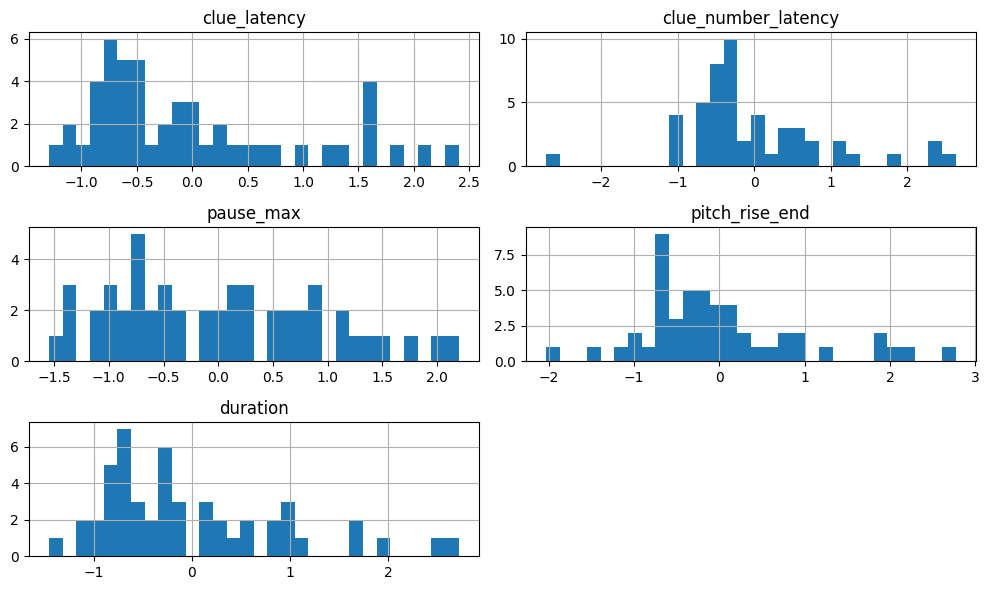

In [16]:
# visualize skewness of most skewed features
skewed_cols = ["pause_before_clue", "clue_latency", "clue_number_latency", "pause_max", "pitch_rise_end", "pause_mid_speech", "duration"]
# skewed_cols = ["clue_latency", "clue_number_latency", "pause_max", "pitch_rise_end", "duration"]
df_norm[skewed_cols].hist(bins=30, figsize=(10, 6))
plt.tight_layout()
plt.show()

In [17]:
# apply log transform to stabilize variance
for col in skewed_cols:
    df_norm[col] = np.log1p(df_norm[col].clip(lower=0))

In [18]:
df_norm[skewed_cols].skew()

clue_latency           1.350266
clue_number_latency    1.688433
pause_max              1.067555
pitch_rise_end         1.682021
duration               1.519940
dtype: float64

## 4. Collapse labels into 3 classes

In [19]:
# Define mapping: 1-2 → Non-confident, 3 → Neutral, 4-5 → Confident
def collapse_confidence(label):
    if label in [1, 2]:
        return "Non-confident"
    elif label == 3:
        return "Neutral"
    elif label in [4, 5]:
        return "Confident"
    else:
        return np.nan  # just in case

def collapse_difficulty(label):
    if label in [1, 2]:
        return "Easy"
    elif label == 3:
        return "Neutral"
    elif label in [4, 5]:
        return "Difficult"
    else:
        return np.nan  # just in case

df_norm['confidence_3class'] = df_norm['confidence'].apply(collapse_confidence)
df_norm['difficulty_3class'] = df_norm['difficulty'].apply(collapse_difficulty)

In [20]:
df_norm['confidence_3class'].value_counts()

confidence_3class
Confident        25
Neutral          13
Non-confident    12
Name: count, dtype: int64

In [21]:
df_norm['difficulty_3class'].value_counts()

difficulty_3class
Easy         26
Difficult    15
Neutral       9
Name: count, dtype: int64

In [22]:
df_norm.columns

Index(['clue_id', 'confidence', 'difficulty', 'transcript',
       'clue_word_frequency', 'duration', 'clue_latency',
       'clue_number_latency', 'speech_rate', 'speech_ratio',
       'articulation_rate', 'pause_count', 'pause_mean', 'pause_max',
       'filler_count', 'repetition_count', 'disfluency',
       'verbal_hesitation_count', 'meta_comment_presence', 'pitch_mean',
       'pitch_std', 'pitch_slope', 'pitch_rise_end', 'energy_mean',
       'energy_std', 'jitter', 'shimmer', 'hnr', 'Spymaster ID',
       'confidence_3class', 'difficulty_3class'],
      dtype='str')

In [23]:
df_norm = df_norm.drop(columns=["Spymaster ID", "confidence", "difficulty"])
df_norm = df_norm.rename(columns={
    'confidence_3class': 'confidence',
    'difficulty_3class': 'difficulty'
})


OSError: Cannot save file into a non-existent directory: 'data'

In [24]:
df_norm.to_csv('../data/clean_audio_data_v3.csv', index=False)